## Loading dataset

In [1]:
from MLtools import ImageData
from torch.utils.data import DataLoader

image_folder = "resized_fruits"
xml_path = "annotations.xml"

train_data = ImageData(image_folder, xml_path)

In [7]:
image, mask = train_data[1000]

In [8]:
image.shape

(3, 640, 640)

In [9]:
mask.shape

(640, 640)

In [10]:
len(train_data)

5020

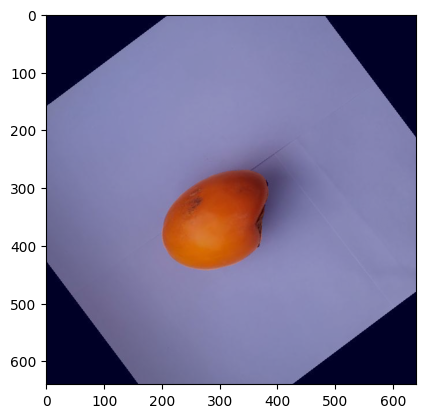

In [11]:
ImageData.draw_appled_mask(image, mask)

In [6]:
BS = 2
train_loader = DataLoader(train_data, batch_size=BS, shuffle=False)

## Appling model

In [7]:
from MLtools import SC_Model
from torchsummary import summary
import torch

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model = SC_Model().to(device)
print(device)

train_losses = []
val_losses   = []

summary(model, (3,640,640))

cuda:0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 640, 640]           1,792
       BatchNorm2d-2         [-1, 64, 640, 640]             128
         LeakyReLU-3         [-1, 64, 640, 640]               0
            Conv2d-4         [-1, 64, 640, 640]          36,928
       BatchNorm2d-5         [-1, 64, 640, 640]             128
         LeakyReLU-6         [-1, 64, 640, 640]               0
         MaxPool2d-7         [-1, 64, 320, 320]               0
         Dropout2d-8         [-1, 64, 320, 320]               0
            Conv2d-9        [-1, 128, 320, 320]          73,856
      BatchNorm2d-10        [-1, 128, 320, 320]             256
        LeakyReLU-11        [-1, 128, 320, 320]               0
           Conv2d-12        [-1, 128, 320, 320]         147,584
      BatchNorm2d-13        [-1, 128, 320, 320]             256
        LeakyReLU-14        [-1,

In [8]:
batch, target = next(iter(train_loader))

with torch.no_grad():
    output = model(batch.float().to(device))

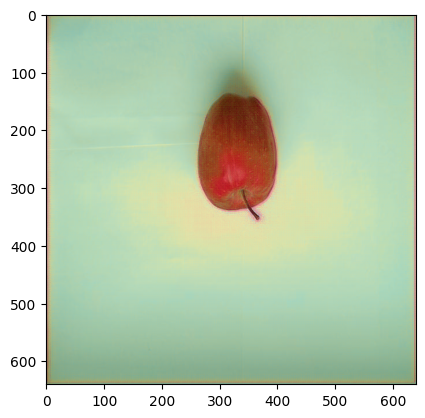

In [9]:
ImageData.draw_appled_mask(batch[0], output[0,0].to('cpu'))

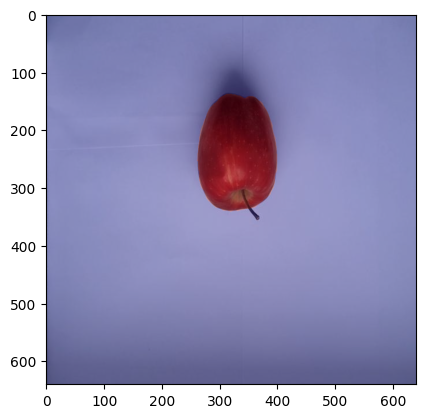

In [10]:
ImageData.draw_appled_mask(batch[0], target[0])

In [15]:
from utils import aug_dataset

# аугментация всех данных

# aug_dataset(train_data, 20)

0it [00:00, ?it/s]